## Building and Analyzing Binary Classification Systems

### Machine Learning Alrorithms
### By Jay Vardhan Ghildiyal a1953779

## Data Exploration and Analysis

### Data Inspection

In [ ]:
import numpy as np

# loading the dataset
data = np.load("mnist_1_7_subsets.npz")

# checking the data type of the data variable
print(type(data))
# so this is a dictionary , as opposed to a pandas dataframe

# checking the keys of the data variable
print(list(data.keys()))

<class 'numpy.lib.npyio.NpzFile'>
['train_data', 'train_targets', 'test_data', 'test_targets']


numpy.lib.npyio.NpzFile = a NumPy zip file object — basically a container that holds multiple arrays inside it (like a dictionary)

now that we know the contents and the name of the keys, we can seperate them according to their roles

In [ ]:
# create different arrays for each key
X_train = data["train_data"]
y_train = data["train_targets"]
X_test  = data["test_data"]
y_test  = data["test_targets"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (100, 28, 28)
y_train shape: (100,)
X_test shape:  (1000, 28, 28)
y_test shape:  (1000,)


100 samples, each with 784 features (pixels). 

Grayscale image → each pixel has just 1 value representing brightness, from 0 to 255:

0 = black
255 = white
anything in between = a shade of grey

So for MNIST, each of the 784 numbers is just the brightness of one pixel. No colour information at all.

In [19]:
print("X_train dtype:", X_train.dtype)
print("Pixel value range: min =", X_train.min(), "| max =", X_train.max())

print("\nTraining labels:", np.unique(y_train))
print("Class counts in training set:")
for label in np.unique(y_train):
    print(f"  Digit {label}: {np.sum(y_train == label)} samples")

print("\nClass counts in test set:")
for label in np.unique(y_test):
    print(f"  Digit {label}: {np.sum(y_test == label)} samples")

X_train dtype: uint8
Pixel value range: min = 0 | max = 255

Training labels: [1 7]
Class counts in training set:
  Digit 1: 50 samples
  Digit 7: 50 samples

Class counts in test set:
  Digit 1: 100 samples
  Digit 7: 900 samples


something interesting :

Test Digit 1: 100 samples
Test Digit 7: 900 samples

pretty heavy imbalance. might need to use precision and recall. (f1 also ?)

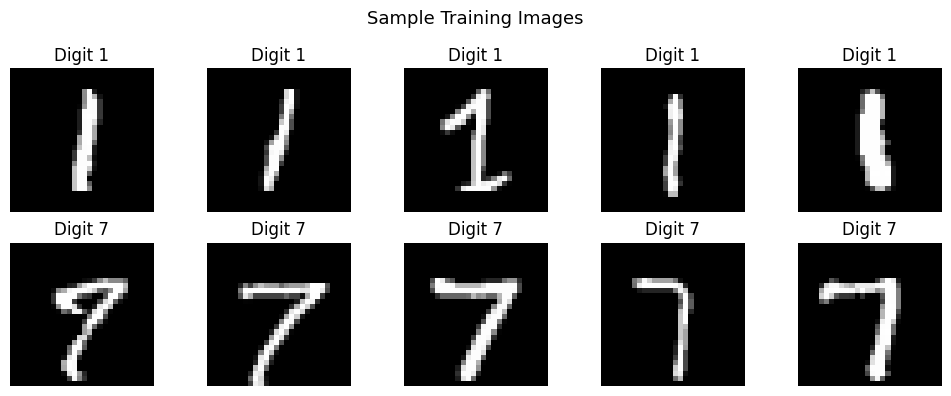

In [ ]:
import matplotlib.pyplot as plt

# create a 2 x 5 grid with image ratio as 10 : 4
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, digit in enumerate([1, 7]):
    # find first 5 indices of the current digit that are equal to digit
    idxs = np.where(y_train == digit)[0][:5]
    for j, idx in enumerate(idxs):
        axes[i, j].imshow(X_train[idx], cmap="gray")
        axes[i, j].axis("off")
        axes[i, j].set_title(f"Digit {digit}")

plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

### Data Pre-Processing

In [ ]:
# flatenning the images from 28x28 to 784
X_train_flat = X_train.reshape(100, -1)
X_test_flat  = X_test.reshape(1000, -1)

# normalizing the pixel values / features
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat  / 255.0

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape: ", X_test_flat.shape)
print("Pixel range: min =", X_train_flat.min(), "| max =", X_train_flat.max())

X_train_flat shape: (100, 784)
X_test_flat shape:  (1000, 784)
Pixel range: min = 0.0 | max = 1.0


we have flatten the array so that linear or non-linear classifiers can use them right 

Numerical stability — models internally do lots of multiplications and additions. Large values like 255 can cause the numbers to get very large very fast, leading to unstable training or overflow issues.

Convergence speed — Logistic Regression uses gradient descent under the hood. Smaller, consistent values help it converge faster and more reliably.

Good habit — in practice you almost always normalise, so it's worth building the habit even when it's not strictly critical.

### Summary for report

The dataset was loaded from a .npz file, a NumPy archive format that stores multiple named arrays — similar to a dictionary of arrays. Four arrays were extracted: training images, training labels, test images, and test labels.
The training set contains 100 samples and the test set contains 1000 samples, each image being 28×28 pixels in grayscale. Pixel values originally ranged from 0–255, where 0 represents black and 255 represents white.
The training set is perfectly balanced — 50 samples per class. However, the test set is heavily imbalanced — 100 samples of digit 1 vs 900 samples of digit 7 (a 10/90 split). This means raw accuracy alone can be misleading, so evaluation metrics like precision, recall, and F1-score should be reported per class.
Two preprocessing steps were applied:

Flattening — each 28×28 image was reshaped into a 784-dimensional vector, as most classical ML classifiers expect 1D feature vectors.
Normalisation — pixel values were scaled from [0, 255] to [0, 1] by dividing by 255, which improves numerical stability and convergence speed.

Sources:

- NumPy .npz format: https://numpy.org/doc/stable/reference/generated/numpy.load.html
- MNIST dataset description: http://yann.lecun.com/exdb/mnist/
- Feature scaling & normalisation: https://scikit-learn.org/stable/modules/preprocessing.html
- Imbalanced classes & evaluation metrics: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report